In [1]:
# ==============================================
# 1. Install Required Libraries
# ==============================================
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.5 MB/s eta 0:00:00


In [2]:
# ==============================================
# 2. Import Libraries
# ==============================================
import ultralytics
import torch
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from ultralytics import YOLO
from google.colab import drive
import zipfile

print("=" * 80)
print("ENVIRONMENT VERIFICATION")
print("=" * 80)
print(f"Ultralytics YOLO Version : {ultralytics.__version__}")
print(f"PyTorch Version          : {torch.__version__}")
print(f"CUDA Available           : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name                 : {torch.cuda.get_device_name(0)}")
    print(f"Total GPU Memory         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print("=" * 80)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ENVIRONMENT VERIFICATION
Ultralytics YOLO Version : 8.4.74
PyTorch Version          : 2.11.0+cu128
CUDA Available           : True
GPU Name                 : NVIDIA A100-SXM4-40GB
Total GPU Memory         : 42.41 GB


In [3]:
# ==============================================
# 3. Mount Google Drive and Extract Dataset
# ==============================================
drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/door.yolov8.zip'
extract_to = '/content/dataset'

os.makedirs(extract_to, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Dataset extracted successfully.")
print("Dataset directory contents:", os.listdir(extract_to))

Mounted at /content/drive
Dataset extracted successfully.
Dataset directory contents: ['test', 'train', 'valid', 'README.roboflow.txt', 'README.dataset.txt', 'data.yaml']


In [4]:
# ==============================================
# 4. Set Random Seed for Reproducibility
# ==============================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f"Random seed set to: {SEED}")

Random seed set to: 42


In [5]:
# ==============================================
# 5. Load Pretrained Model
# ==============================================
model = YOLO('yolov8s.pt')
print("Pretrained YOLOv8s model loaded successfully.")

Pretrained YOLOv8s model loaded successfully.


In [7]:
# ==============================================
# 6. Train the Model
# ==============================================
print("=" * 80)
print("MODEL TRAINING CONFIGURATION")
print("=" * 80)
print(f"Epochs              : 50")
print(f"Early Stopping      : Patience = 5")
print(f"Batch Size          : 128")
print(f"Image Size          : 640")
print(f"AMP (Mixed Precision): Enabled")
print(f"Deterministic       : True")
print(f"Random Seed         : {SEED}")
print("=" * 80)

results = model.train(
    data='/content/dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=128,
    name='door_detection_final_v1',
    plots=True,
    patience=5,
    save=True,
    amp=True,
    seed=SEED,
    deterministic=True,
    workers=8,
    verbose=True
)

print("\n" + "=" * 80)
print("TRAINING COMPLETED")
print("=" * 80)
print(f"Best model saved at: {os.path.join(results.save_dir, 'weights', 'best.pt')}")
print("=" * 80)

MODEL TRAINING CONFIGURATION
Epochs              : 50
Early Stopping      : Patience = 5
Batch Size          : 128
Image Size          : 640
AMP (Mixed Precision): Enabled
Deterministic       : True
Random Seed         : 42
Ultralytics 8.4.74 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0

In [8]:
# ==============================================
# 7. Load Training Results
# ==============================================
results_csv_path = os.path.join(results.save_dir, 'results.csv')

if os.path.exists(results_csv_path):
    df = pd.read_csv(results_csv_path)
    print("\nTraining Results (Last 5 Epochs):")
    display(df.tail())
else:
    print("results.csv file not found.")


Training Results (Last 5 Epochs):


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
43,44,3221.23,0.33629,0.22044,0.99851,0.97628,0.84123,0.90745,0.80538,0.58923,0.43969,0.83005,0.000297,0.000297,0.000297
44,45,3293.30,0.32435,0.21373,0.98550,0.94462,0.85521,0.89833,0.80303,0.57380,0.43328,0.80933,0.000258,0.000258,0.000258
45,46,3365.09,0.31952,0.20943,0.98173,0.96321,0.84123,0.90693,0.80664,0.59005,0.42602,0.82951,0.000218,0.000218,0.000218
46,47,3436.62,0.30900,0.20107,0.97682,0.97400,0.84401,0.90427,0.80631,0.57114,0.40948,0.82542,0.000178,0.000178,0.000178
47,48,3508.35,0.29536,0.19668,0.96636,0.94872,0.86072,0.89913,0.80456,0.57442,0.41810,0.82874,0.000139,0.000139,0.000139


Training performance graph saved at: /content/results/training_performance.png


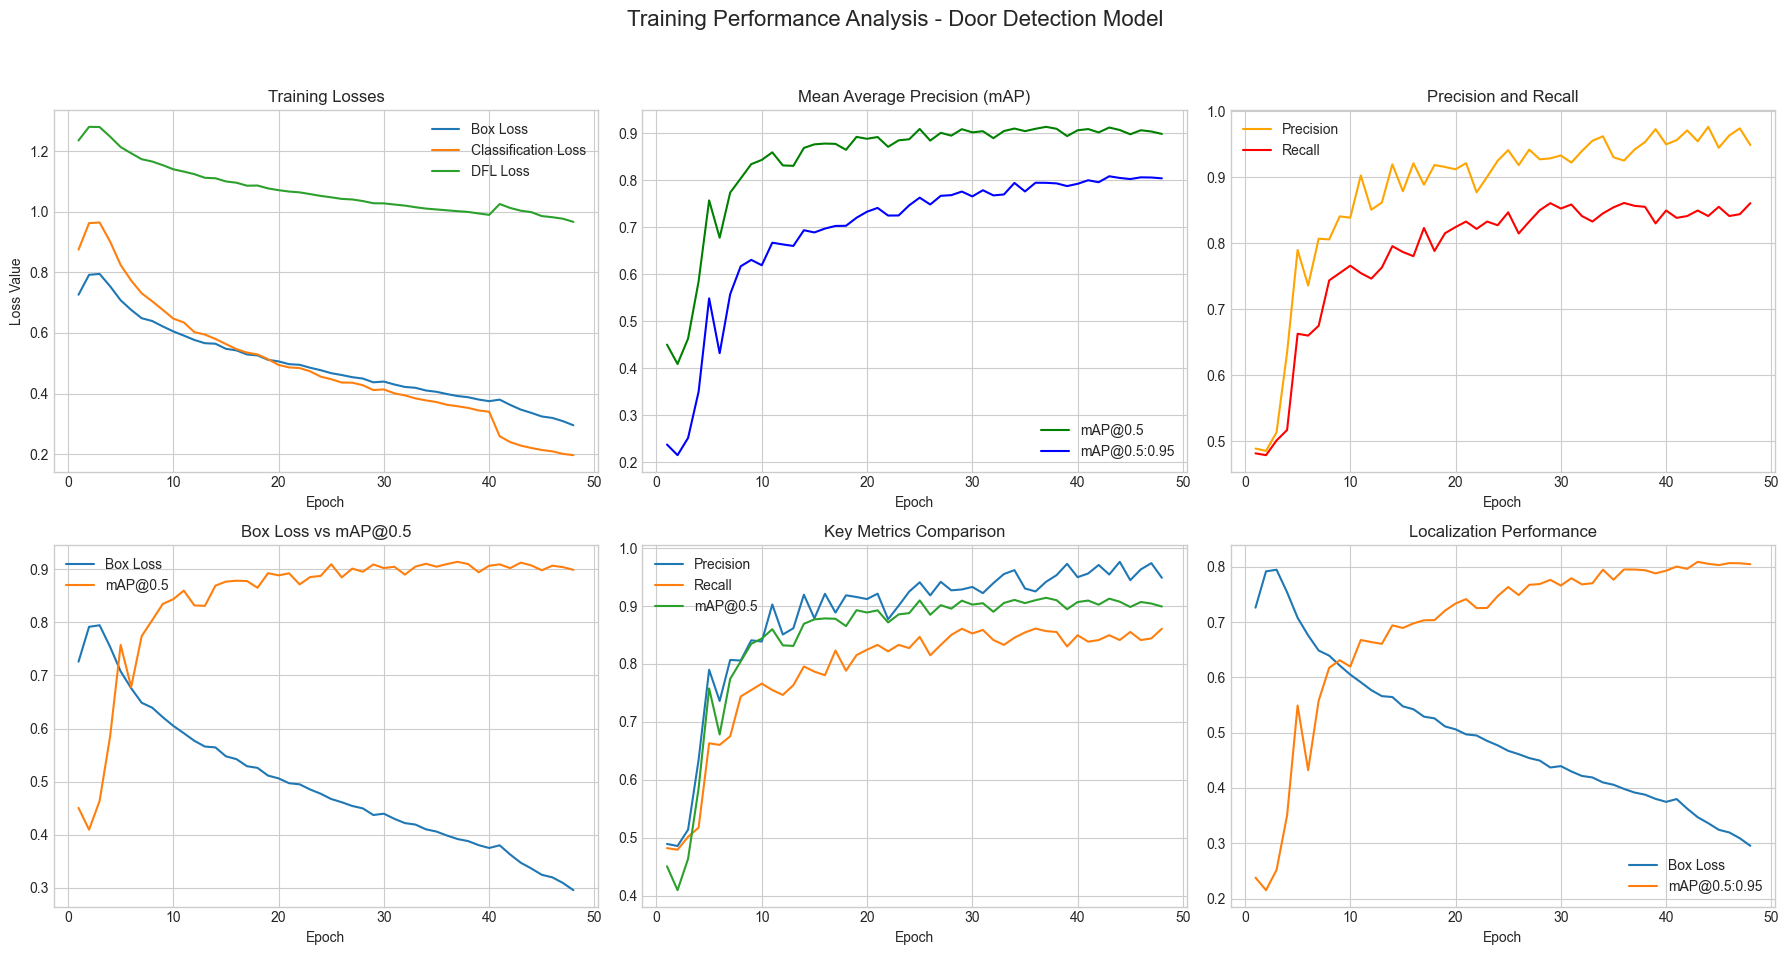

In [9]:
# ==============================================
# 8. Generate and Save Training Performance Graphs
# ==============================================
if os.path.exists(results_csv_path):
    df = pd.read_csv(results_csv_path)

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Training Performance Analysis - Door Detection Model', fontsize=16, fontweight='bold')

    # Training Losses
    axes[0, 0].plot(df['epoch'], df['train/box_loss'], label='Box Loss')
    axes[0, 0].plot(df['epoch'], df['train/cls_loss'], label='Classification Loss')
    axes[0, 0].plot(df['epoch'], df['train/dfl_loss'], label='DFL Loss')
    axes[0, 0].set_title('Training Losses')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss Value')
    axes[0, 0].legend()

    # mAP Curves
    axes[0, 1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@0.5', color='green')
    axes[0, 1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95', color='blue')
    axes[0, 1].set_title('Mean Average Precision (mAP)')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].legend()

    # Precision & Recall
    axes[0, 2].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='orange')
    axes[0, 2].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='red')
    axes[0, 2].set_title('Precision and Recall')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].legend()

    # F1 Score or Box Loss vs mAP
    if 'metrics/F1(B)' in df.columns:
        axes[1, 0].plot(df['epoch'], df['metrics/F1(B)'], label='F1 Score', color='purple')
        axes[1, 0].set_title('F1 Score')
    else:
        axes[1, 0].plot(df['epoch'], df['train/box_loss'], label='Box Loss')
        axes[1, 0].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@0.5')
        axes[1, 0].set_title('Box Loss vs mAP@0.5')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].legend()

    # Key Metrics Comparison
    axes[1, 1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
    axes[1, 1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
    axes[1, 1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@0.5')
    axes[1, 1].set_title('Key Metrics Comparison')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].legend()

    # Localization Performance
    axes[1, 2].plot(df['epoch'], df['train/box_loss'], label='Box Loss')
    axes[1, 2].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95')
    axes[1, 2].set_title('Localization Performance')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # Save graph
    os.makedirs('/content/results', exist_ok=True)
    plt.savefig('/content/results/training_performance.png', dpi=300, bbox_inches='tight')
    print("Training performance graph saved at: /content/results/training_performance.png")
    plt.show()

In [10]:
# ==============================================
# 9. Evaluate Best Model on Test Set
# ==============================================
best_model_path = os.path.join(results.save_dir, 'weights', 'best.pt')
best_model = YOLO(best_model_path)

print("=" * 80)
print("FINAL EVALUATION ON TEST SET")
print("=" * 80)

metrics = best_model.val(data='/content/dataset/data.yaml', split='test')

print(f"\nTest Set Performance Metrics:")
print(f"  mAP@0.5          : {metrics.box.map50:.4f}")
print(f"  mAP@0.5:0.95     : {metrics.box.map:.4f}")
print(f"  Precision        : {metrics.box.p.mean():.4f}")
print(f"  Recall           : {metrics.box.r.mean():.4f}")
print(f"  F1 Score         : {metrics.box.f1.mean():.4f}")
print("=" * 80)

FINAL EVALUATION ON TEST SET
Ultralytics 8.4.74 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1570.3±586.5 MB/s, size: 40.5 KB)
val: Scanning /content/dataset/test/labels... 404 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 404/404 1.5Kit/s 0.3s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 8.0it/s 3.2s
                   all        404        416      0.967      0.915      0.962      0.857
Speed: 0.9ms preprocess, 2.0ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/runs/detect/val

Test Set Performance Metrics:
  mAP@0.5          : 0.9617
  mAP@0.5:0.95     : 0.8566
  Precision        : 0.9670
  Recall           : 0.9153
  F1 Score         : 0.9405


In [11]:
# ==============================================
# 10. Generate Confusion Matrix
# ==============================================
print("=" * 80)
print("GENERATING CONFUSION MATRIX")
print("=" * 80)

metrics = best_model.val(data='/content/dataset/data.yaml', split='test', plots=True)
print("Confusion matrix generated and saved by Ultralytics in results folder.")

GENERATING CONFUSION MATRIX
Ultralytics 8.4.74 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1759.3±728.8 MB/s, size: 36.6 KB)
val: Scanning /content/dataset/test/labels.cache... 404 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 404/404 169.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 7.8it/s 3.3s
                   all        404        416      0.967      0.915      0.962      0.857
Speed: 1.0ms preprocess, 1.3ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val-2
Confusion matrix generated and saved by Ultralytics in results folder.


In [12]:
# ==============================================
# 11. Inference Speed Benchmark
# ==============================================
print("=" * 80)
print("INFERENCE SPEED BENCHMARK (CPU)")
print("=" * 80)

test_image_dir = '/content/dataset/test/images'
if os.path.exists(test_image_dir):
    image_files = [f for f in os.listdir(test_image_dir) if f.endswith(('.jpg', '.png'))]
    if image_files:
        test_image = os.path.join(test_image_dir, image_files[0])

        # Warmup
        for _ in range(5):
            _ = best_model(test_image, verbose=False, device='cpu')

        # Benchmark
        start_time = time.time()
        for _ in range(50):
            _ = best_model(test_image, verbose=False, device='cpu')
        end_time = time.time()

        avg_time = (end_time - start_time) / 50
        fps = 1 / avg_time

        print(f"Average Inference Time : {avg_time * 1000:.2f} ms per image")
        print(f"Frames Per Second (FPS): {fps:.2f}")
        print(f"Model Size             : {os.path.getsize(best_model_path) / (1024 * 1024):.2f} MB")
print("=" * 80)

INFERENCE SPEED BENCHMARK (CPU)
Average Inference Time : 112.89 ms per image
Frames Per Second (FPS): 8.86
Model Size             : 21.47 MB


In [13]:
# ==============================================
# 12. Download Best Model
# ==============================================
from google.colab import files
files.download(best_model_path)
print("Best model downloaded successfully.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Best model downloaded successfully.
